#ordinary least squares

#homoscedastic the variance doesnt increase

#the residuals are normally distributed

#are additive instead of multiplicative

funciones vinculantes generalized linear models

gala is reference level

diferences in means 

y is the mean ciderph of the reference category gala

mean of the braeburn y de ahi se saca el slope

the first level of the factor 

a single straight line will connect to the means of the categories

en 2 si pero en 3 ni en 4!

k=4

we create k-1 dummy variables d1,d2,d3

GALA 000
BRAEBURN 100
Granny smidth 010
honey crisp 001

b0 + b1d1 + b2d2 + b3d3 + e

mean of the reference level Gala

al means 

por eso se hace asi para que siempre este una como referencia gala

y las otras se prenden y se apagan.

siempre necesitas 2 por eso apagas las otras!

4 - 1 slopes


In [1]:
library(mlr)
library(tidyverse)

Loading required package: ParamHelpers

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
data(Ozone, package = 'mlbench')

In [3]:
ozonetib<-as_tibble(Ozone)
ozonetib

V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13
<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,4,3,5480,8,20,NA,NA,5000,-15,30.56,200
1,2,5,3,5660,6,NA,38,NA,NA,-14,NA,300
1,3,6,3,5710,4,28,40,NA,2693,-25,47.66,250
1,4,7,5,5700,3,37,45,NA,590,-24,55.04,100
1,5,1,5,5760,3,51,54,45.32,1450,25,57.02,60
1,6,2,6,5720,4,69,35,49.64,1568,15,53.78,60
1,7,3,4,5790,6,19,45,46.40,2631,-33,54.14,100
1,8,4,4,5790,3,25,55,52.70,554,-28,64.76,250
1,9,5,6,5700,3,73,41,48.02,2083,23,52.52,120


In [4]:
names(ozonetib)<-c(
    'Month',
    'Date',
    'Day',
    'Ozone',
    'Press_height',
    'Wind',
    'Humid',
    'Temp_Sand',
    'Temp_Monte',
    'Inv_height',
    'Press_grad',
    'Inv_temp',
    'Visib'
)

In [5]:
ozonetib

Month,Date,Day,Ozone,Press_height,Wind,Humid,Temp_Sand,Temp_Monte,Inv_height,Press_grad,Inv_temp,Visib
<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,4,3,5480,8,20,NA,NA,5000,-15,30.56,200
1,2,5,3,5660,6,NA,38,NA,NA,-14,NA,300
1,3,6,3,5710,4,28,40,NA,2693,-25,47.66,250
1,4,7,5,5700,3,37,45,NA,590,-24,55.04,100
1,5,1,5,5760,3,51,54,45.32,1450,25,57.02,60
1,6,2,6,5720,4,69,35,49.64,1568,15,53.78,60
1,7,3,4,5790,6,19,45,46.40,2631,-33,54.14,100
1,8,4,4,5790,3,25,55,52.70,554,-28,64.76,250
1,9,5,6,5700,3,73,41,48.02,2083,23,52.52,120


In [6]:
map_dbl(ozonetib, ~sum(is.na(.)))

Month         Date          Day        Ozone Press_height         Wind 
           0            0            0            5           12            0 
       Humid    Temp_Sand   Temp_Monte   Inv_height   Press_grad     Inv_temp 
          15            2          139           15            1           14 
       Visib 
           0

In [7]:
a<-mutate_all(ozonetib,as.numeric)

In [8]:
ozoneclean<-a %>% filter(is.na(Ozone) == FALSE)

In [9]:
ozoneuntidy<-gather(ozoneclean,key = 'Variable',value = 'Value', -Ozone)
ozoneuntidy

Ozone,Variable,Value
<dbl>,<chr>,<dbl>
3,Month,1
3,Month,1
3,Month,1
5,Month,1
5,Month,1
6,Month,1
4,Month,1
4,Month,1
6,Month,1


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
Warning message:
“Removed 196 rows containing non-finite outside the scale range (`stat_smooth()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 196 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 196 rows containing missing values or values outside the scale range (`geom_point()`).”
Saving 6.67 x 6.67 in image
`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
Warning message:
“Removed 196 rows containing non-finite outside the scale range (`stat_smooth()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 196 rows containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 196 rows containing missing values or values outside the scale range (`geom_point()`).”


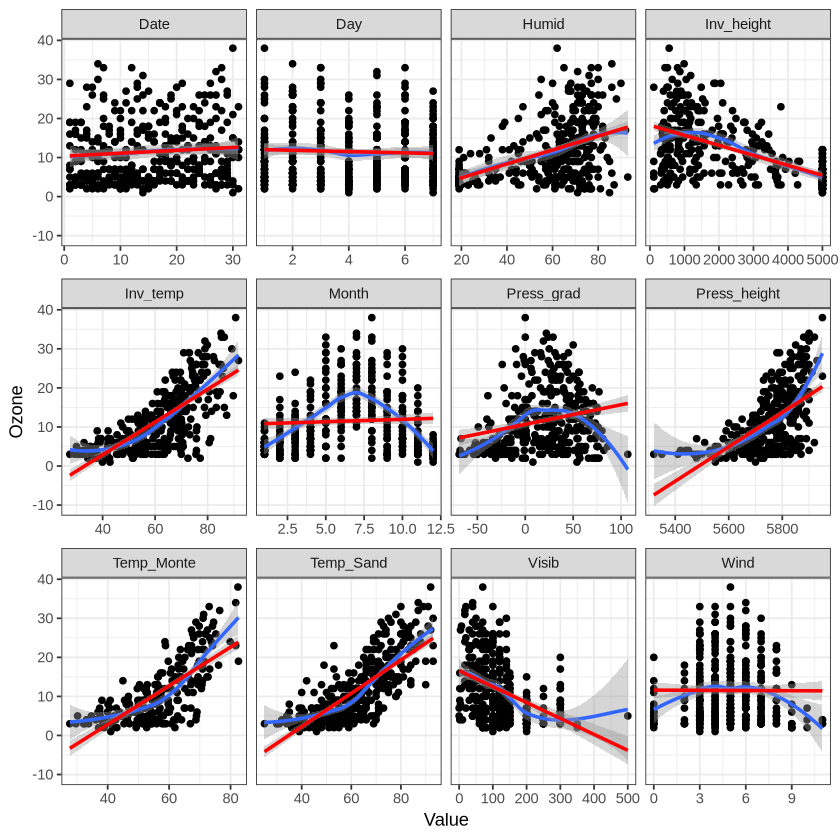

In [10]:

(
    ggplot(ozoneuntidy,aes(Value,Ozone)) + 
    facet_wrap(~Variable, scale = 'free_x') +
    geom_point() + 
    theme_bw() + 
    geom_smooth() + 
    geom_smooth(method = 'lm', col='red')
)

#puede usar gam!
ggsave('ozone.png')

In [11]:
?imputations

imputations {mlr},R Documentation
const,(any) Constant valued use for imputation.
multiplier,(numeric(1)) Value that stored minimum or maximum is multiplied with when imputation is done.
min,"(numeric(1)) Lower bound for uniform distribution. If NA (default), it will be estimated from the data."
max,"(numeric(1)) Upper bound for uniform distribution. If NA (default), it will be estimated from the data."
mu,(numeric(1)) Mean of normal distribution. If missing it will be estimated from the data.
sd,(numeric(1)) Standard deviation of normal distribution. If missing it will be estimated from the data.
breaks,"(numeric(1)) Number of breaks to use in graphics::hist. If missing, defaults to auto-detection via “Sturges”."
use.mids,"(logical(1)) If x is numeric and a histogram is used, impute with bin mids (default) or instead draw uniformly distributed samples within bin range."
learner,(Learner | character(1)) Supervised learner. Its predictions will be used for imputations. If you pass a string the learner will be created via makeLearner. Note that the target column is not available for this operation.
features,(character) Features to use in learner for prediction. Default is NULL which uses all available features except the target column of the original task.


#split the dataset into cases 
#decide on a regression algorithm to predict what the missing values would have been!

#if categorical we choose classification algorithm
#if numerical we choose regression algorithm

que interesante logistic regression no funciona por los mising values!

#missing value imputation

likelihood of a missing value depends on the value itself. porque el salario es bajo!

buenos

mcar
mar

y

malos
mnar


In [12]:
imputemethod<-imputeLearner('regr.rpart')

In [13]:
imputemethod

$learn
function (data, target, col, learner, features) 
{
    constructor = getTaskConstructorForLearner(learner)
    if (is.null(features)) {
        features = setdiff(names(data), target)
    }
    else {
        not.ok = which(features %nin% names(data))
        if (length(not.ok)) {
            stopf("Features for imputation not found in data: '%s'", 
                collapse(features[not.ok]))
        }
        not.ok = which.first(target %in% features)
        if (length(not.ok)) {
            stopf("Target column used as feature for imputation: '%s'", 
                target[not.ok])
        }
        if (col %nin% features) {
            features = c(col, features)
        }
    }
    impute.feats = setdiff(features, col)
    if (anyMissing(data[impute.feats]) && !hasLearnerProperties(learner, 
        "missings")) {
        has.na = vlapply(data[impute.feats], anyMissing)
        wrong.feats = clipString(collapse(colnames(data[impute.feats])[has.na], 
            ", "), 50L)


In [14]:
ozoneclean

Month,Date,Day,Ozone,Press_height,Wind,Humid,Temp_Sand,Temp_Monte,Inv_height,Press_grad,Inv_temp,Visib
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,4,3,5480,8,20,NA,NA,5000,-15,30.56,200
1,2,5,3,5660,6,NA,38,NA,NA,-14,NA,300
1,3,6,3,5710,4,28,40,NA,2693,-25,47.66,250
1,4,7,5,5700,3,37,45,NA,590,-24,55.04,100
1,5,1,5,5760,3,51,54,45.32,1450,25,57.02,60
1,6,2,6,5720,4,69,35,49.64,1568,15,53.78,60
1,7,3,4,5790,6,19,45,46.40,2631,-33,54.14,100
1,8,4,4,5790,3,25,55,52.70,554,-28,64.76,250
1,9,5,6,5700,3,73,41,48.02,2083,23,52.52,120


In [15]:
ozoneimp<-impute(as.data.frame(ozoneclean), classes = list(numeric = imputemethod))

In [16]:
ozoneimp$data

Month,Date,Day,Ozone,Press_height,Wind,Humid,Temp_Sand,Temp_Monte,Inv_height,Press_grad,Inv_temp,Visib
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,4,3,5480,8,20.00000,33,33.98000,5000.000,-15,30.56000,200
1,2,5,3,5660,6,31.00000,38,51.27180,4960.907,-14,38.24255,300
1,3,6,3,5710,4,28.00000,40,51.27180,2693.000,-25,47.66000,250
1,4,7,5,5700,3,37.00000,45,51.27180,590.000,-24,55.04000,100
1,5,1,5,5760,3,51.00000,54,45.32000,1450.000,25,57.02000,60
1,6,2,6,5720,4,69.00000,35,49.64000,1568.000,15,53.78000,60
1,7,3,4,5790,6,19.00000,45,46.40000,2631.000,-33,54.14000,100
1,8,4,4,5790,3,25.00000,55,52.70000,554.000,-28,64.76000,250
1,9,5,6,5700,3,73.00000,41,48.02000,2083.000,23,52.52000,120


In [17]:
ozonetask<-makeRegrTask(data = ozoneimp$data, target = 'Ozone')

In [18]:
lin<-makeLearner('regr.lm')